In [ ]:
"""
Starting with k=2, fit a k-means clustering model and record the `.inertia_` parameter of the fitted model.
Repeat step 2 for k from 2 to 30, recording the `.inertia_` value for each k.
Plot the inertia values from k=2..30 and use this plot to select a value for k.
"""

'\nUse the CSV file to create a data frame, where each row corresponds to an actor, each column represents a genre, and each cell captures how many times that row’s actor has appeared in that column’s genre\nUsing this data frame as your data matrix, use the k-means package in scikit-learn sklearn.cluster.KMeansLinks to an external site. to extract k=8 clusters from the data.\nInitialize the model using KMeans(n_clusters=8)\nFit this model to the data and get cluster predictions back using the model.fit_predict()\nPrint the number of actors per cluster you have found\nFor each cluster, print a random sample of 5 actors in that cluster to get a sense of who is in each cluster\nOne easy way to do this sampling is to use Pandas to create a data frame with the predicted cluster labels as a column and the actor IDs from your original actor x genre matrix as the index. Then you can use df.groupby("cluster") to get sub-data frames for each cluster.\n'

In [2]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [3]:
file_name = "imdb_movies_2000to2022.actorXgenre.csv"


df = pd.read_csv(file_name, index_col="actor_id")
df.head()


,Comedy,Fantasy,Romance,Drama,Mystery,Thriller,Action,Biography,Crime,War,...,Horror,Documentary,Sport,News,Family,Music,Unnamed: 22,Western,Short,Reality-TV
actor_id,,,,,,,,,,,,,,,,,,,,,
nm0000212,7.0,1.0,6.0,6.0,1.0,2.0,1.0,1.0,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
nm0413168,7.0,3.0,5.0,12.0,5.0,2.0,14.0,4.0,6.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
nm0000630,8.0,2.0,6.0,14.0,2.0,3.0,4.0,5.0,1.0,1.0,...,3.0,7.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
nm0005227,10.0,1.0,2.0,2.0,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
nm0864851,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


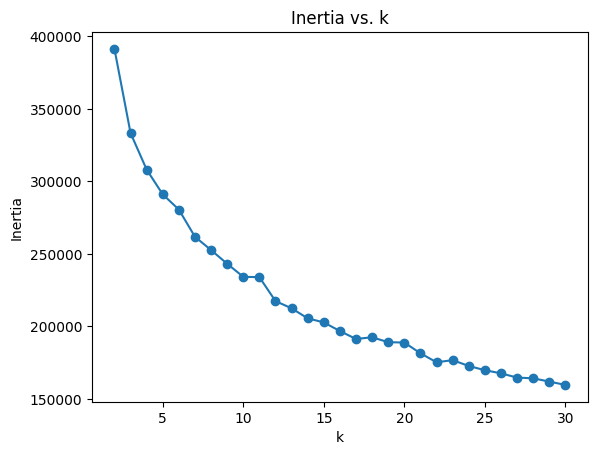

[391327.8682959376, 333296.0933842243, 308100.3449328593, 290999.5963627084, 280518.5033077156, 261768.39136610567, 252593.92163530417, 243151.0088454918, 234150.0514008749, 233925.58439094442, 217412.1192528267, 212422.22900539797, 205509.77740337435, 202710.4881351047, 196755.11033694443, 191269.6835258589, 192468.54992726626, 189054.86813893, 188833.39843004063, 181417.24727867736, 175218.8620762102, 176663.7200936553, 172674.98227315777, 169734.5082598633, 167597.0707837866, 164655.7686172346, 164157.23554266596, 161898.13927544001, 159591.01546774697]


In [4]:


k = 2
inertia_values = []
while k <= 30:
    model = KMeans(n_clusters=k)
    model.fit(df)
    inertia_values.append(model.inertia_)
    k += 1



plt.plot(range(2, 31), inertia_values, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Inertia vs. k")
plt.show()

print(inertia_values)


In [ ]:
"""
Good value would be around 9-11, the spike between 10 and 11 seem to be noticable
"""

In [15]:
from sklearn.cluster import DBSCAN

df = pd.read_csv(file_name, index_col="actor_id")
df.head()

model = DBSCAN(eps=0.5, min_samples=5)
model.fit(df)

df["cluster"] = model.labels_
print("Number of clusters:", df["cluster"].nunique())
print("Top 5 actors in each cluster:")
for cluster in df["cluster"].unique():
    print(f"Cluster {cluster}:")
    print(df[df["cluster"] == cluster].head())

Number of clusters: 466
Top 5 actors in each cluster:
Cluster -1:
           Comedy  Fantasy  Romance  Drama  Mystery  Thriller  Action  \
actor_id                                                                
nm0000212     7.0      1.0      6.0    6.0      1.0       2.0     1.0   
nm0413168     7.0      3.0      5.0   12.0      5.0       2.0    14.0   
nm0000630     8.0      2.0      6.0   14.0      2.0       3.0     4.0   
nm0005227    10.0      1.0      2.0    2.0      0.0       1.0     1.0   
nm0828288     8.0      0.0      0.0    4.0      3.0      10.0     1.0   

           Biography  Crime  War  ...  Documentary  Sport  News  Family  \
actor_id                          ...                                     
nm0000212        1.0    2.0  1.0  ...          0.0    0.0   0.0     0.0   
nm0413168        4.0    6.0  0.0  ...          0.0    0.0   0.0     0.0   
nm0000630        5.0    1.0  1.0  ...          7.0    3.0   1.0     0.0   
nm0005227        0.0    0.0  0.0  ...          